# Perplexities Analysis

**Dataset: StarPep (sequences from 10 to 100 amino acids)**

In [2]:
import pandas as pd
import numpy as np
from utils.plotting import boxplot

In [3]:
# paths
base_path = '../output/StarPep/PaperNew/2024-12-23T15.40.45-Data_Ingestion/Analysis/'
output_path = './output/graphics/'

# load sequence_length and sequence_perp
sequence_length = pd.read_csv(base_path + 'Sequence-Length.csv')
sequence_perp = pd.read_csv(base_path + 'Sequence-Perplexities.csv')

# merge data
data = sequence_perp.merge(sequence_length, how='inner', on='sequence').drop(columns=['sequence', 'id_x', 'id_y'])

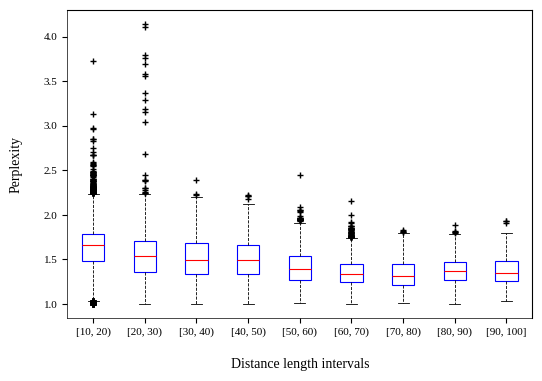

In [4]:
length_max = data['length'].max()
bin_size = 10
bins = np.arange(0, length_max + bin_size, bin_size)
bins[-1] = length_max + 1  # Ensure the last bin includes the max value

data['bin'] = pd.cut(data['length'], bins=bins, right=False)
data['bin'] = data['bin'].cat.rename_categories(lambda x: '[90, 100]' if str(x) == '[90, 101)' else str(x))

x_axis = 'bin'
y_axis = 'perplexity'

#plt = boxplot(data, x_axis, y_axis, 'Distance length intervals', 'Perplexity', y_lim=(0.9, 4), output='boxplot', fig_size=(12, 6))
plt = boxplot(data, x_axis, y_axis, 'Distance length intervals', 'Perplexity', output=f'{output_path}boxplot-perplexities')
plt.show()

In [14]:
# perplexity of the sequences
seq_to_filter = ['MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVSLRPIGASCRDDSECITRLCRKRRCSLSVAQE', 
                 'RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPKPIPRPLPLPRPRPRRIPRPLPLPRPRPRPIPRPLPLPQPQPSPIPRPL']
result = sequence_perp[sequence_perp['sequence'].isin(seq_to_filter)]
result

,id,sequence,perplexity
1938,starPep_01989,RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPK...,1.317876
10477,starPep_11987,MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVS...,1.161721
